# Supervised Learning

This notebook uses simple supervised learning to classify images into classes, without data augmentation

In [1]:

cd ..

/home/lowen/Documents/github/galaxy_class


In [2]:
# install requirements

# if connected to colab


if 'google.colab' in str(get_ipython()):
  print('running on colab')
  %pip install git+https://github.com/henrysky/astroNN.git
else:
  %pip install --upgrade pip
  %pip install -r user-requirements.txt

Note: you may need to restart the kernel to use updated packages.
Ignoring tensorflow: markers 'sys_platform != "linux"' don't match your environment
Note: you may need to restart the kernel to use updated packages.


In [3]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import h5py
import numpy as np
from tensorflow.keras import utils
import os

filepath = 'src/Galaxy10.h5'

if not os.path.exists(filepath):
    print(f"file {filepath} not found")
    print("fetching from http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5...")
    os.makedirs('src', exist_ok=True)
    !wget -P src http://astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5

with h5py.File(filepath, 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

# To convert the labels to categorical 10 classes
labels = utils.to_categorical(labels, 10)

# To convert to desirable type
labels = labels.astype(np.float32)
images = images.astype(np.float32)

2026-08-01 21:36:44.711149: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-01 21:36:44.711181: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-01 21:36:44.712350: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-01 21:36:44.718900: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-01 21:36:45.468113: W tensorflow/compiler/tf2

In [4]:
images.shape

(21785, 69, 69, 3)

In [5]:
# divide images and labels into training and test sets

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.1, random_state=42)

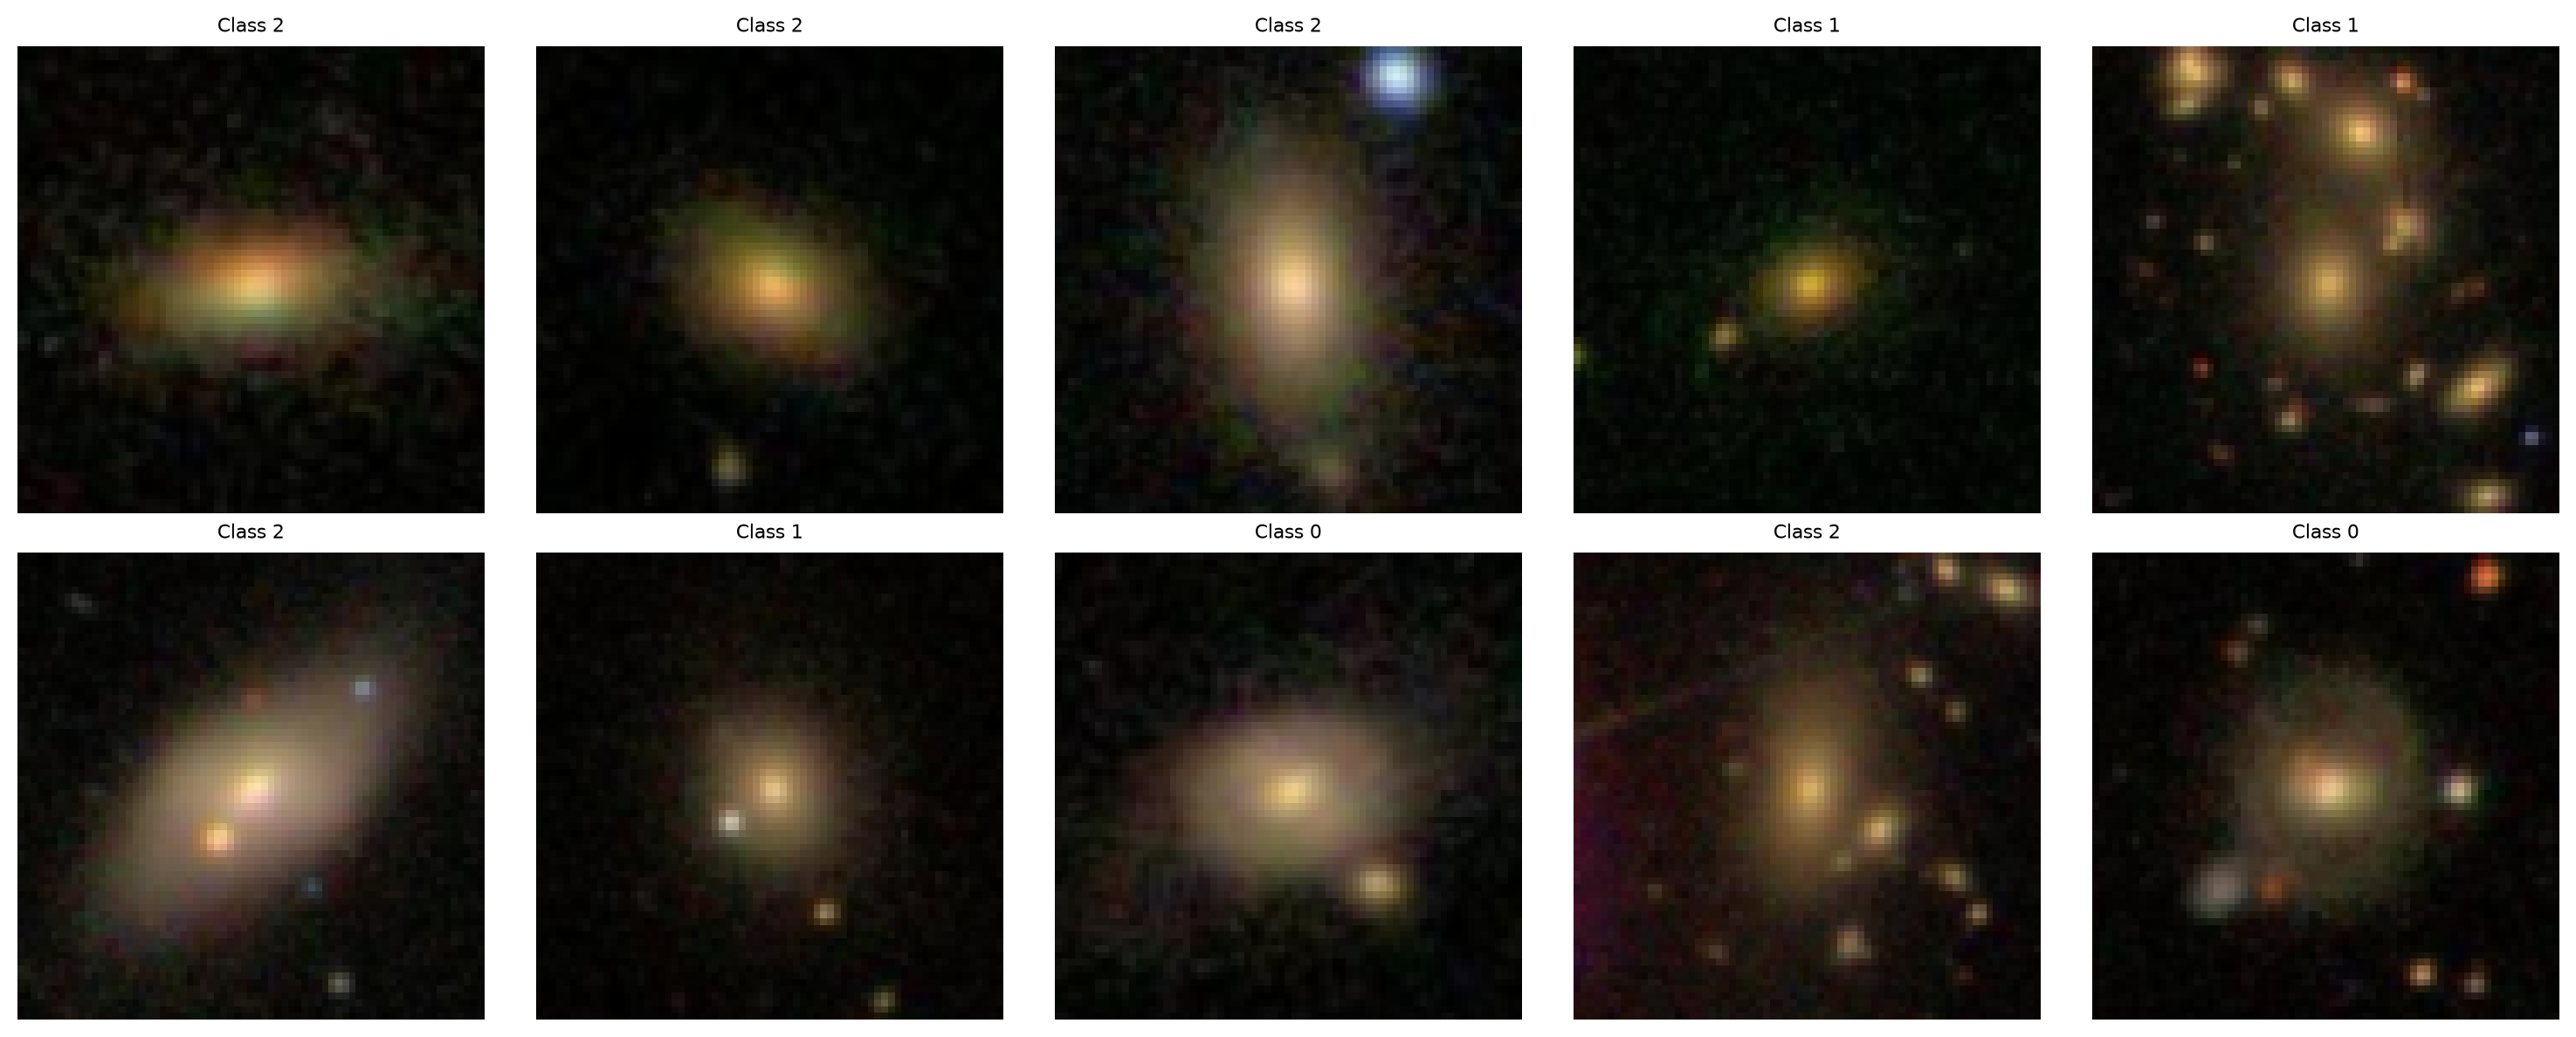

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

idx = np.random.randint(0, y_train.shape[0], size=10)

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train[i].astype(np.uint8))
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/original.png")
plt.show()

In [7]:
# def center_crop(img, crop_size):
#     h, w = img.shape[:2]
#     start_h = (h - crop_size) // 2
#     start_w = (w - crop_size) // 2
#     return img[start_h:start_h + crop_size, start_w:start_w + crop_size]

# crop_size = 128
# X_train_cropped = np.array([center_crop(img, crop_size) for img in X_train])
# X_test_cropped = np.array([center_crop(img, crop_size) for img in X_test])

# print(X_train_cropped.shape)

In [8]:
from PIL import Image
import numpy as np

X_train_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_train
])

X_test_gray = np.array([
    np.array(Image.fromarray(img.astype(np.uint8)).convert('L'))
    for img in X_test
])

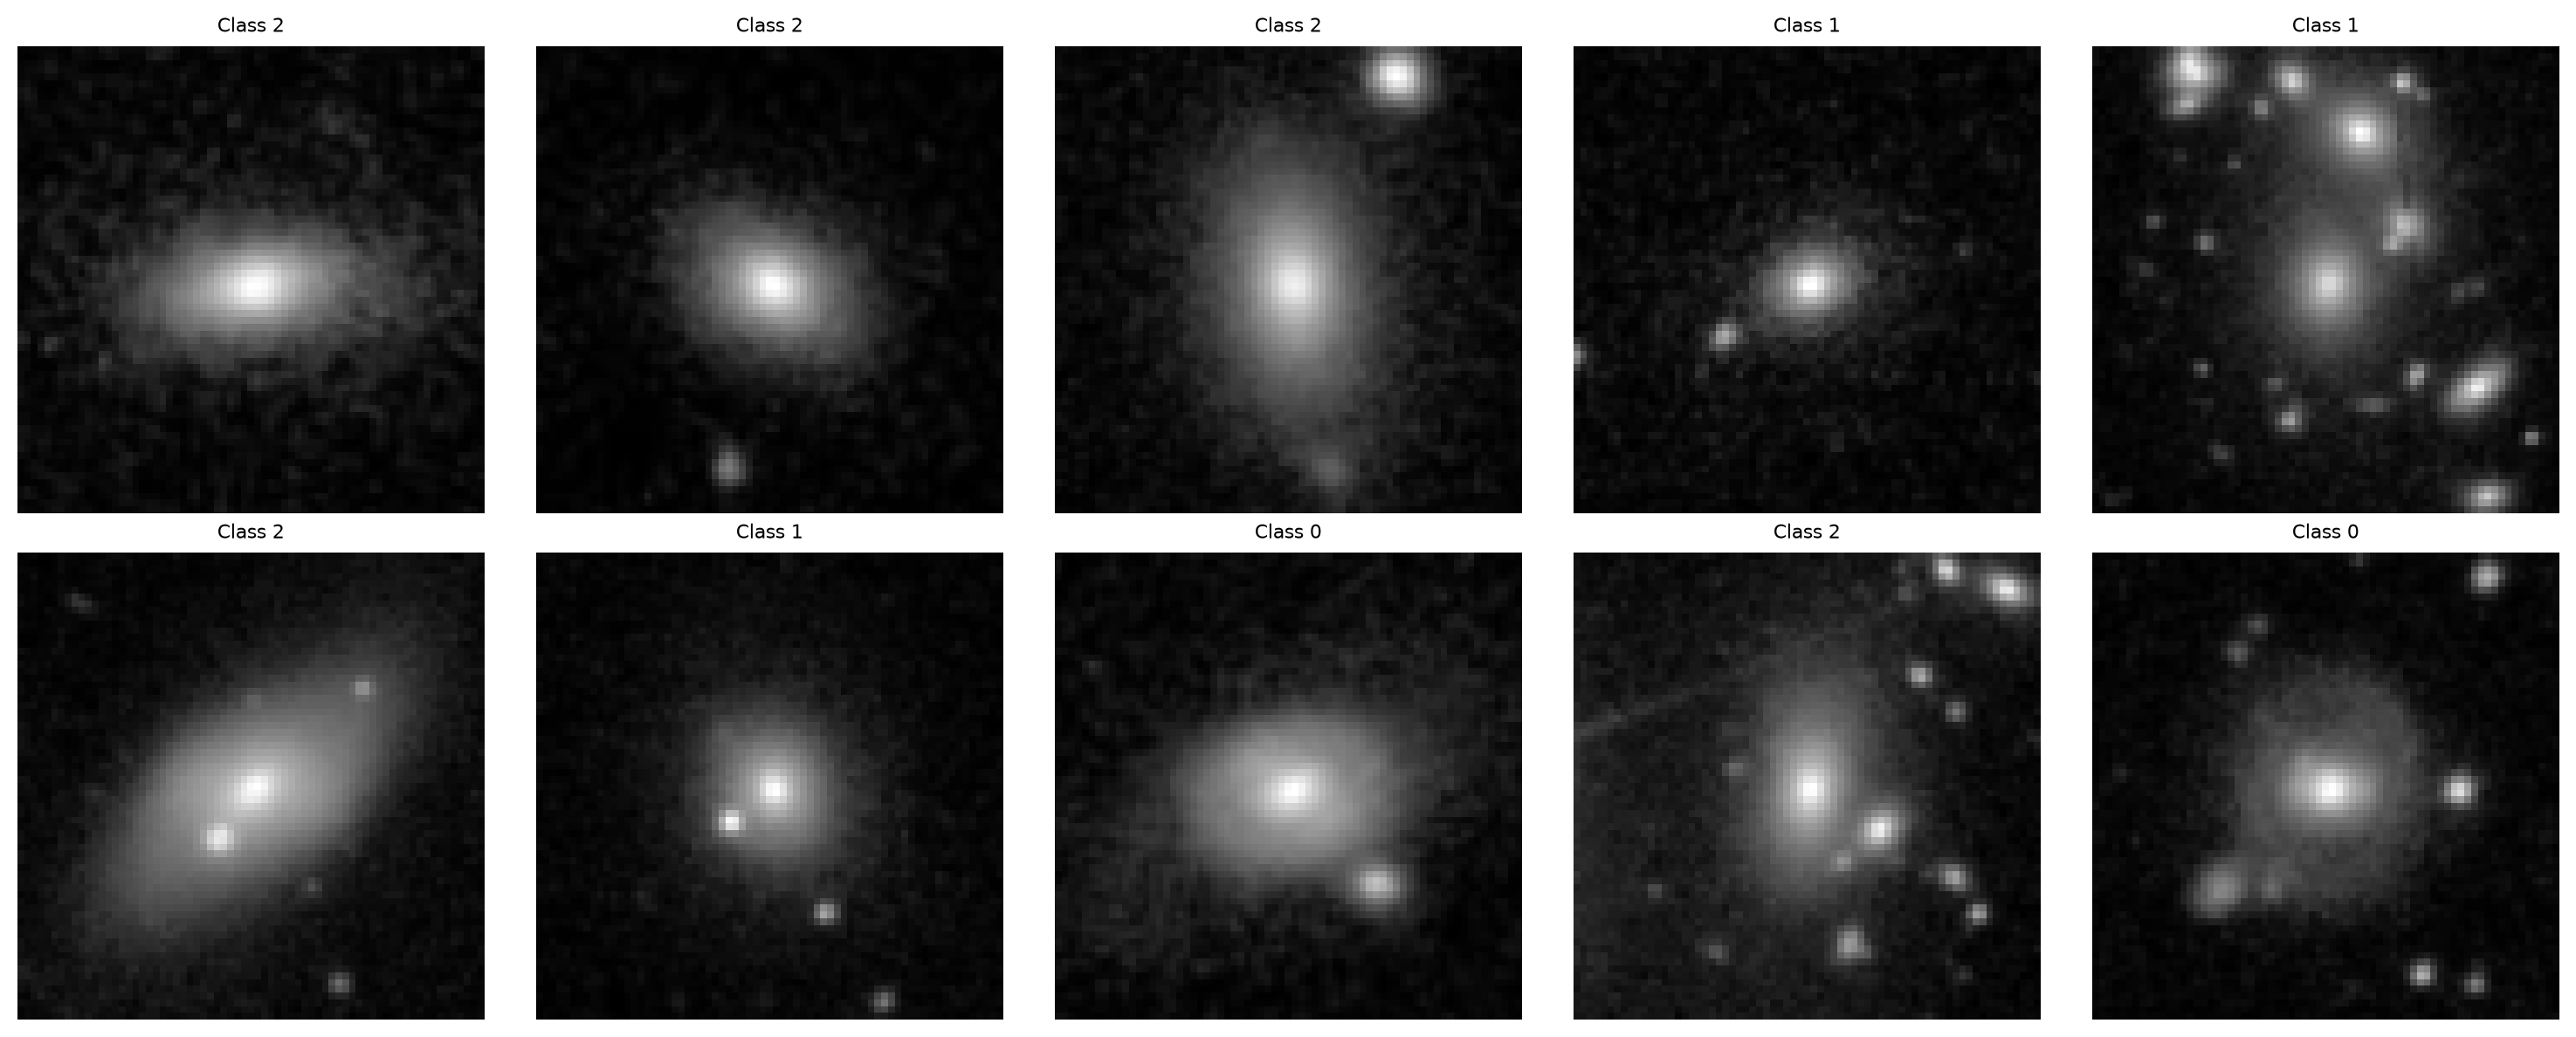

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_train_gray[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Data Cleaning

1. normalization (min-max)
2. normalization using percentiles
3. gaussian / bilateral filter
4. histogram equalization

In [10]:
# Min-max normalization (per-image)

X_min = X_train_gray.min(axis=(1,2), keepdims=True)  
X_max = X_train_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_train_gray - X_min) / (X_max - X_min + 1e-8)  

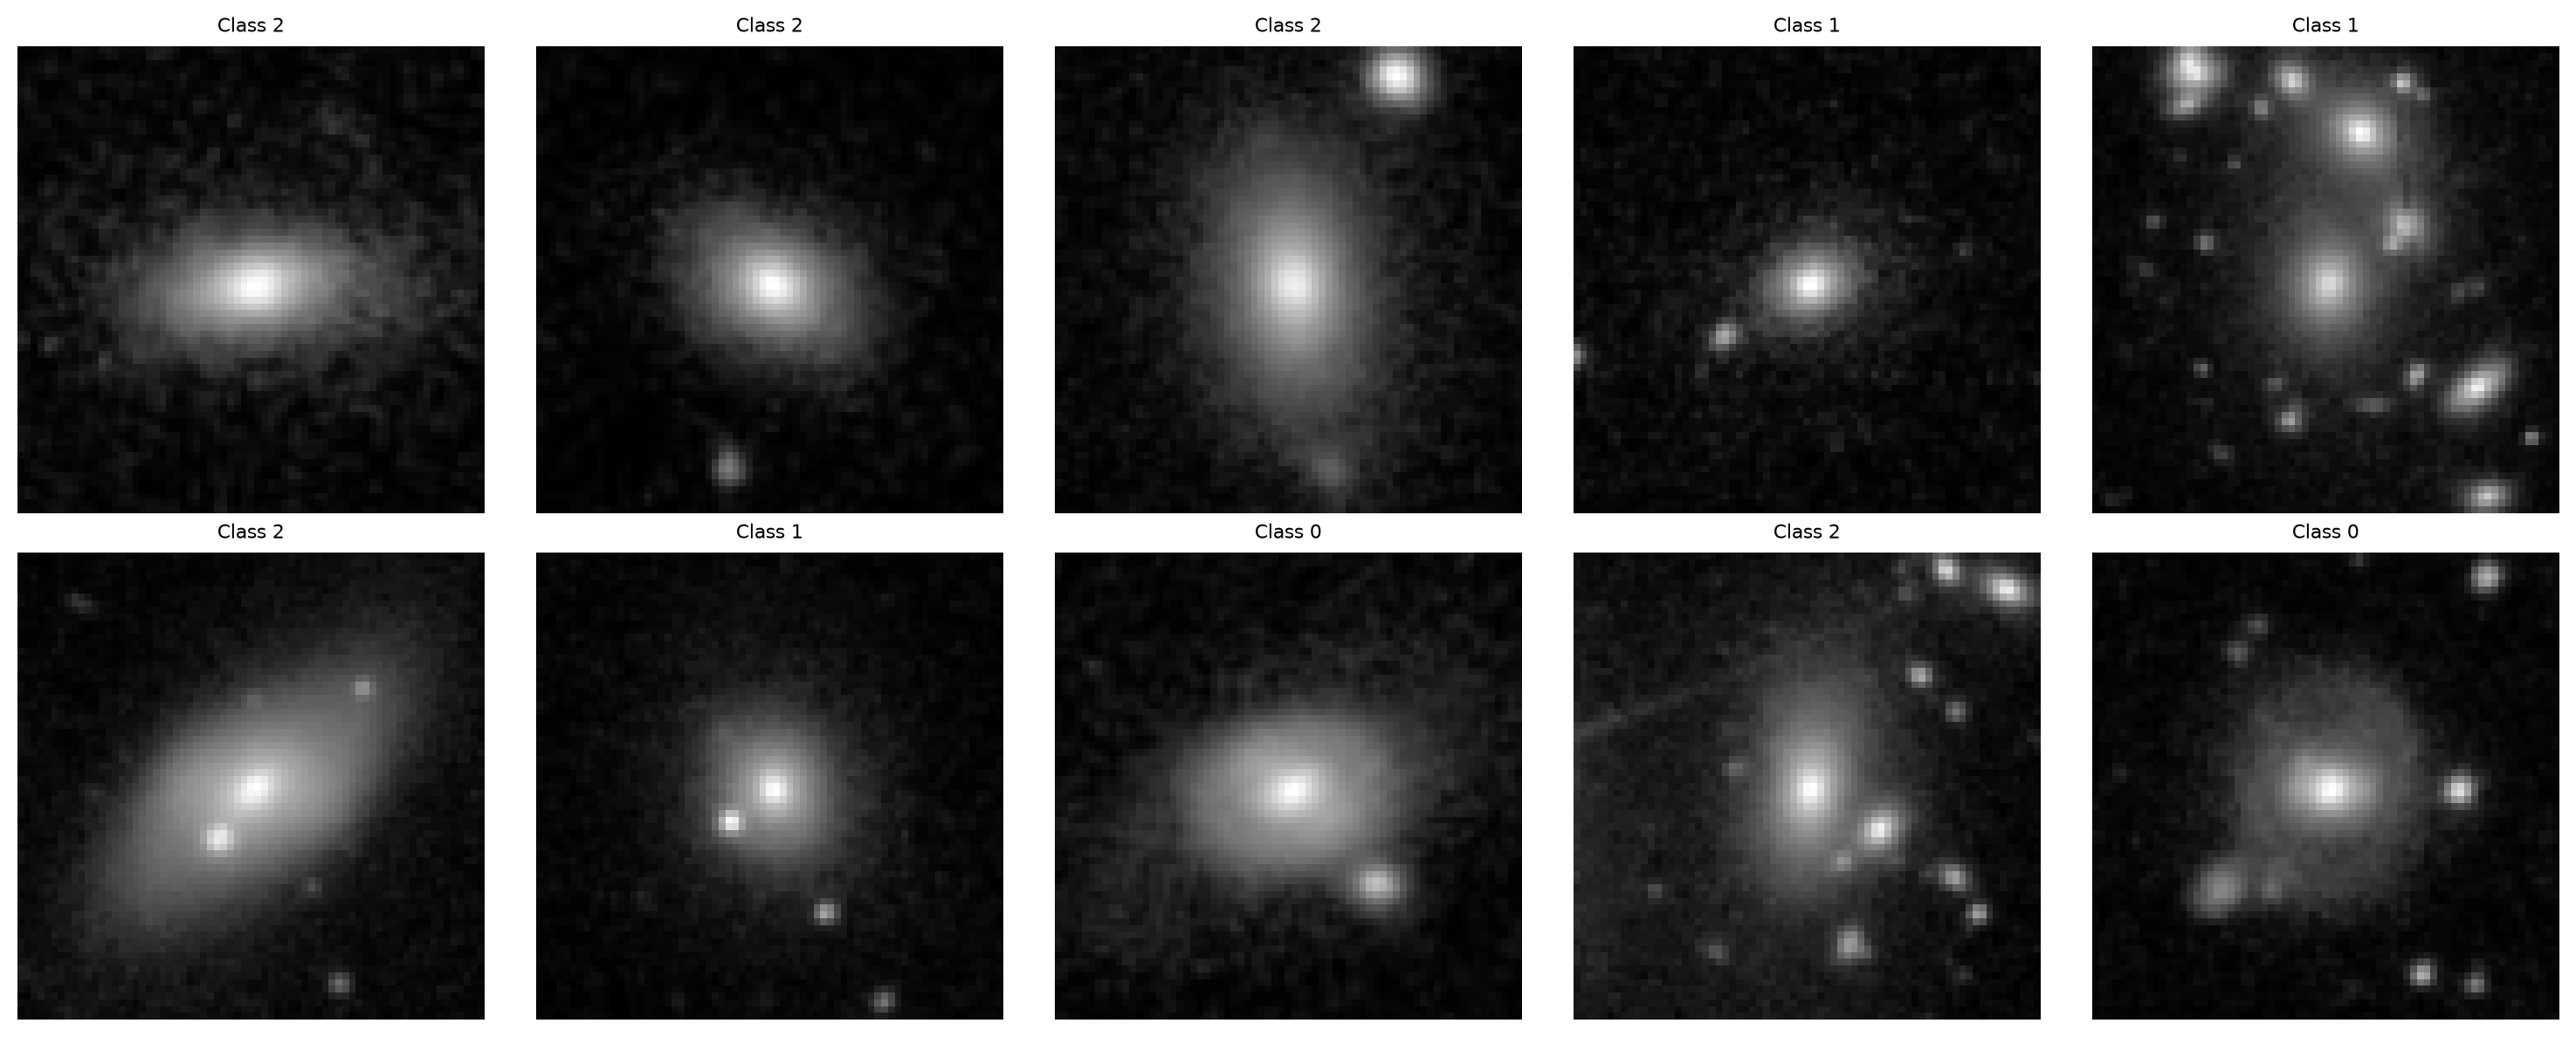

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_norm[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/gray.png")
plt.show()

In [12]:
X_norm.shape

(19606, 69, 69)

In [13]:
# gaussian filter on images

from scipy.ndimage import gaussian_filter

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])

In [14]:
X_gauss.min(), X_gauss.max()

(0.0, 0.9974658839905133)

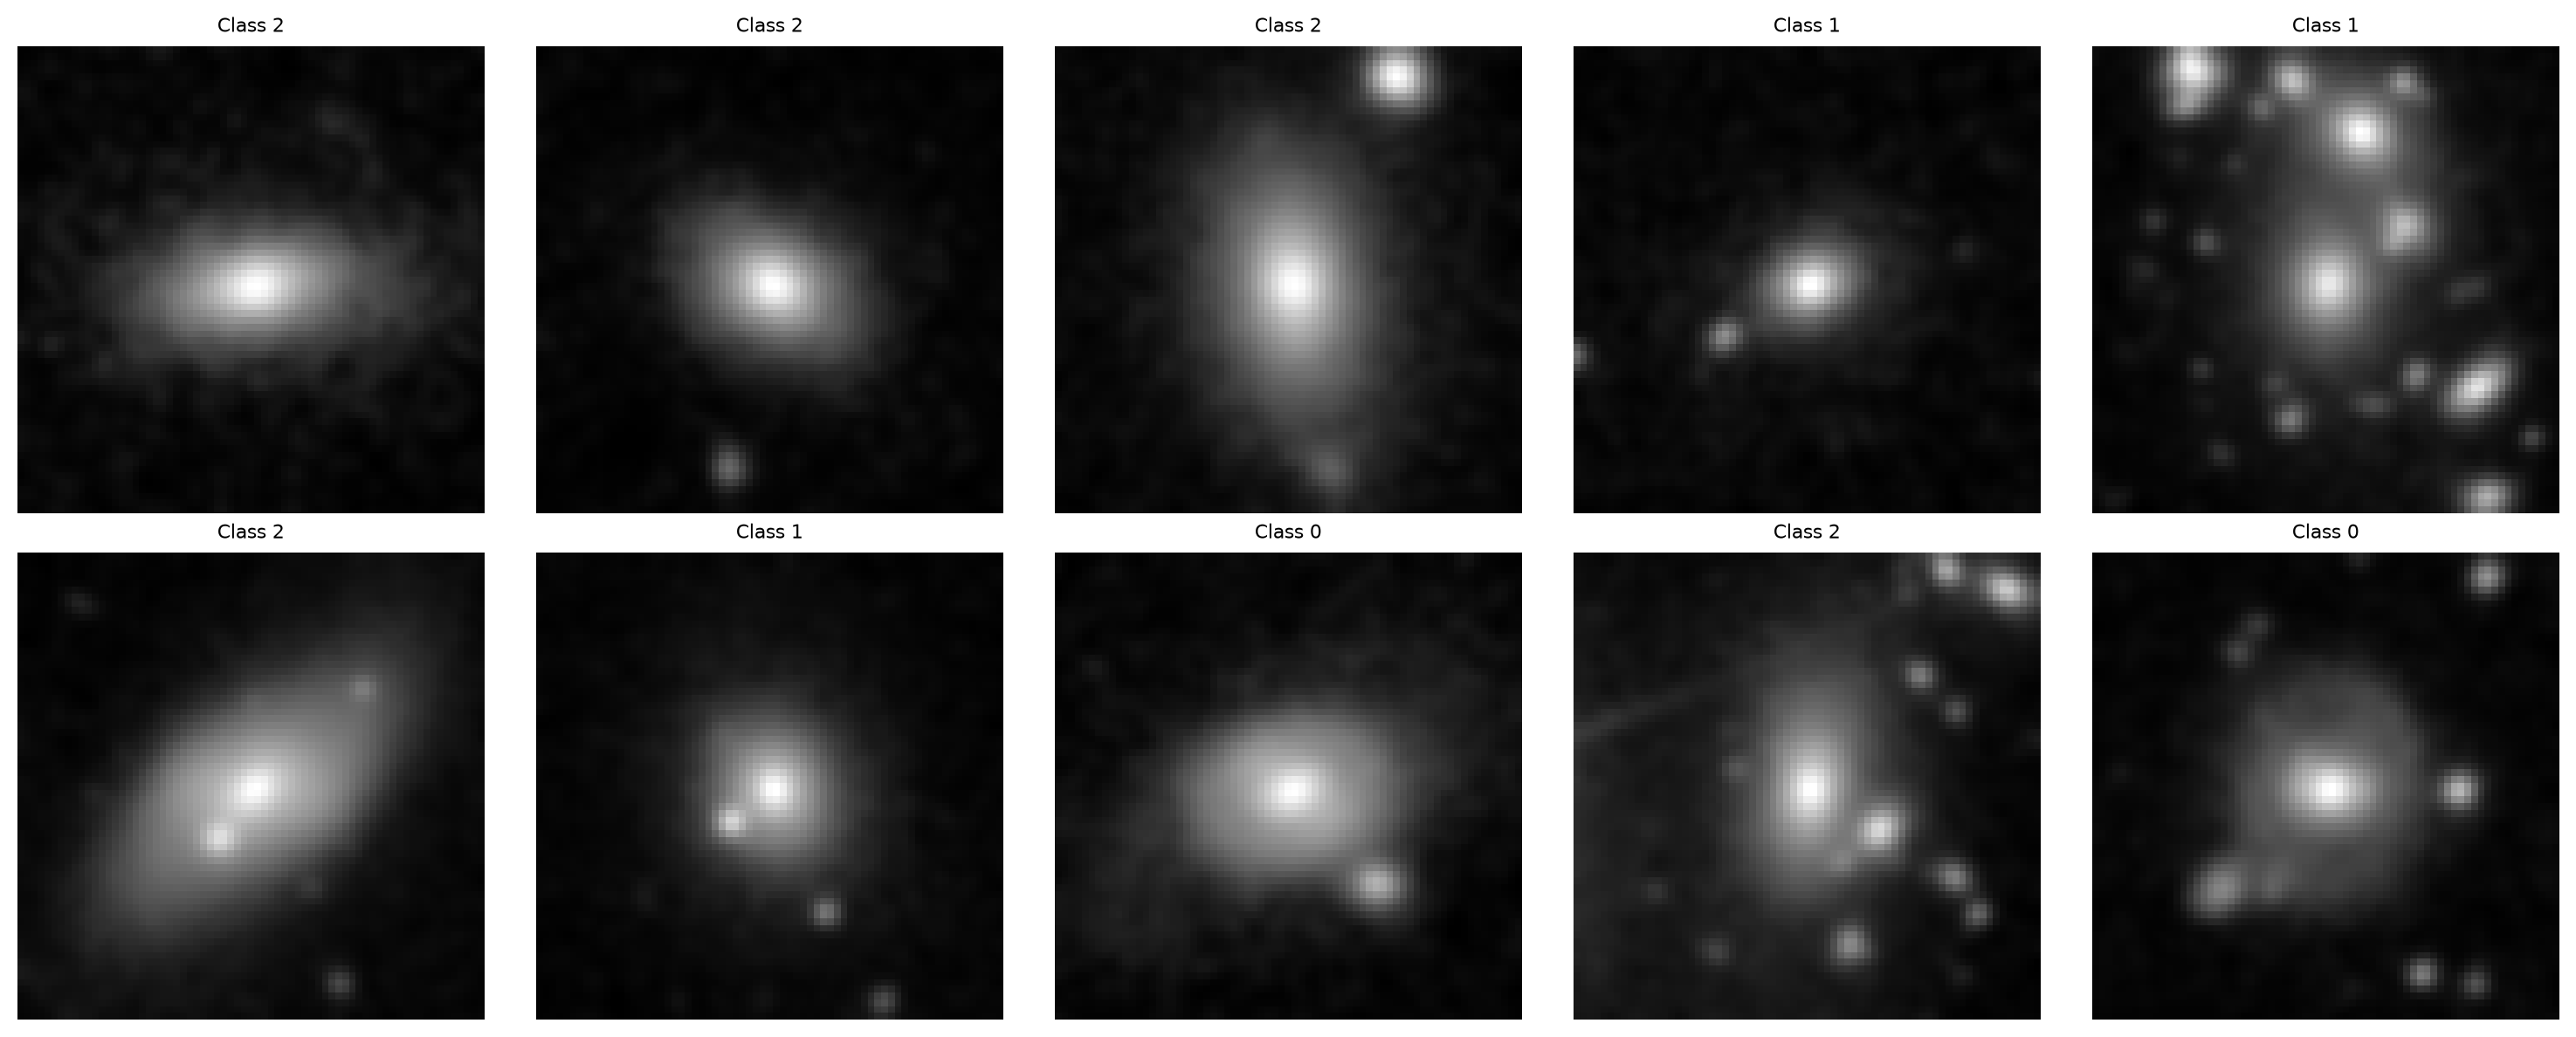

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, i in zip(axes.flat, idx):
    ax.imshow(X_gauss[i], cmap="gray")
    ax.set_title(f"Class {np.argmax(y_train[i])}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
# plt.savefig("plots/gaussian_smooth.png")
plt.show()

In [16]:
# train a model on X_norm (without filters) and X_gauss

X_norm.shape, y_train.shape

((19606, 69, 69), (19606, 10))

### Training

#### without filter

In [17]:
# train a CNN model

import tensorflow as tf
from keras import layers, models

In [18]:

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
model = models.Sequential()

model.add(layers.Input(shape=(69, 69, 1)))

# block 1
model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# block 2
model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
model.add(layers.MaxPooling2D((2, 2)))

# block 3
model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
model.add(layers.GlobalAveragePooling2D())

model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

model.add(layers.Dense(10, activation='softmax'))

2026-08-01 21:36:56.341816: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-01 21:36:56.384689: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-01 21:36:56.384900: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)

In [20]:
X_norm.shape

(19606, 69, 69)

In [21]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_train, axis=1)


In [22]:
X_flat.shape

(19606, 69, 69, 1)

In [23]:
y_train.shape

(19606, 10)

In [24]:
history = model.fit(
    X_flat, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    shuffle=True
)

2026-08-01 21:36:57.453426: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298686096 exceeds 10% of free system memory.
2026-08-01 21:36:57.744400: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298686096 exceeds 10% of free system memory.


Epoch 1/20


2026-08-01 21:36:58.931947: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-08-01 21:36:59.011806: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-08-01 21:36:59.449759: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-08-01 21:36:59.512901: I external/local_xla/xla/service/service.cc:168] XLA service 0x7e5e14b0e3d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-01 21:36:59.512956: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1050, Compute Capability 6.1
2026-08-01 21:36:59.519286: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785613019.616311   13084 device_compiler.

491/491 [==============================] - 9s 11ms/step - loss: 1.2723 - categorical_accuracy: 0.4994 - val_loss: 1.4594 - val_categorical_accuracy: 0.4495
Epoch 2/20
491/491 [==============================] - 5s 9ms/step - loss: 0.8614 - categorical_accuracy: 0.6750 - val_loss: 0.9516 - val_categorical_accuracy: 0.6354
Epoch 3/20
491/491 [==============================] - 5s 9ms/step - loss: 0.7164 - categorical_accuracy: 0.7375 - val_loss: 0.6895 - val_categorical_accuracy: 0.7611
Epoch 4/20
491/491 [==============================] - 5s 9ms/step - loss: 0.6554 - categorical_accuracy: 0.7587 - val_loss: 1.3620 - val_categorical_accuracy: 0.6497
Epoch 5/20
491/491 [==============================] - 5s 9ms/step - loss: 0.6159 - categorical_accuracy: 0.7752 - val_loss: 0.7745 - val_categorical_accuracy: 0.6984
Epoch 6/20
491/491 [==============================] - 5s 9ms/step - loss: 0.5867 - categorical_accuracy: 0.7833 - val_loss: 0.8244 - val_categorical_accuracy: 0.7096
Epoch 7/20
491

In [25]:
train_loss = history.history['loss']
train_acc = history.history['categorical_accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_categorical_accuracy']

print(f'train loss: {train_loss}')
print(f'train acc: {train_acc}')
print(f'val loss: {val_loss}')
print(f'val acc: {val_acc}')

train loss: [1.2723108530044556, 0.8613573908805847, 0.7164025902748108, 0.6553845405578613, 0.6159382462501526, 0.5866585969924927, 0.5604918599128723, 0.5492531061172485, 0.5326244235038757, 0.5082793831825256, 0.5051969289779663, 0.48138701915740967, 0.46467143297195435, 0.4463566541671753, 0.43036091327667236, 0.4165969491004944, 0.3978865146636963, 0.39097142219543457, 0.37448716163635254, 0.35845819115638733]
train acc: [0.4994261562824249, 0.6750191450119019, 0.737503170967102, 0.7587350010871887, 0.775248646736145, 0.7833460569381714, 0.7929737567901611, 0.7983932495117188, 0.802155077457428, 0.8098061680793762, 0.814906895160675, 0.821856677532196, 0.8289977312088013, 0.8410481810569763, 0.8421320915222168, 0.8476791381835938, 0.8553302884101868, 0.8556490540504456, 0.8638740181922913, 0.8674445152282715]
val loss: [1.4594444036483765, 0.9515777826309204, 0.6894737482070923, 1.3620065450668335, 0.7745334506034851, 0.8244268894195557, 0.8796653151512146, 0.7348548769950867, 0.7

In [26]:
y_pred = model.predict(X_flat)

2026-08-01 21:38:35.080998: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 373376664 exceeds 10% of free system memory.
2026-08-01 21:38:35.452118: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 373376664 exceeds 10% of free system memory.


613/613 [==============================] - 2s 3ms/step


In [27]:
y_pred = np.argmax(y_pred, axis=1)

In [28]:
y_true = np.argmax(y_train, axis=1)

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pred, y_true)

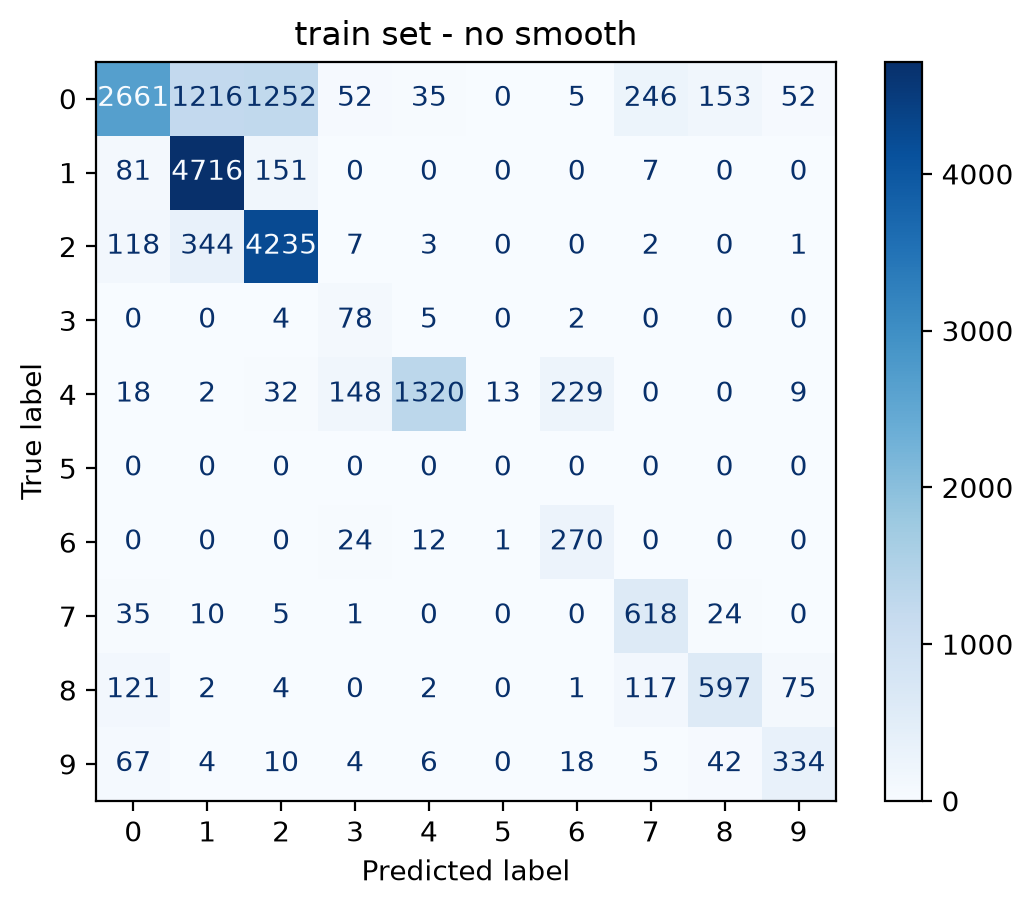

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("train set - no smooth")
# plt.savefig("plots/train_no_smooth.pdf")
plt.show()

#### with filter

In [31]:
X_flat_gauss = X_gauss[..., np.newaxis]

input_shape = (X_norm.shape[1], X_norm.shape[1], 1)
gauss_model = models.Sequential()
gauss_model.add(layers.Input(shape=(69, 69, 1)))

# block 1
gauss_model.add(layers.Conv2D(8, (3, 3), activation="relu", padding="same"))
gauss_model.add(layers.BatchNormalization())
gauss_model.add(layers.MaxPooling2D((2, 2)))

# block 2
gauss_model.add(layers.Conv2D(32, (5, 5), activation="relu", padding="same"))
gauss_model.add(layers.MaxPooling2D((2, 2)))

# block 3
gauss_model.add(layers.Conv2D(64, (3, 3), activation="relu", padding="same"))
gauss_model.add(layers.BatchNormalization())
gauss_model.add(layers.MaxPooling2D((2, 2)))

# converts feature maps → single vector per feature map
gauss_model.add(layers.GlobalAveragePooling2D())

gauss_model.add(layers.Dense(32, activation='relu'))

# model.add(layers.Dropout(0.4))

gauss_model.add(layers.Dense(10, activation='softmax'))

In [32]:
gauss_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["categorical_accuracy"]
)

In [33]:
history = gauss_model.fit(
    X_flat_gauss, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    shuffle=True
)

2026-08-01 21:38:39.037956: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 298686096 exceeds 10% of free system memory.


Epoch 1/20
491/491 [==============================] - 7s 10ms/step - loss: 1.3573 - categorical_accuracy: 0.4732 - val_loss: 1.5619 - val_categorical_accuracy: 0.3503
Epoch 2/20
491/491 [==============================] - 5s 10ms/step - loss: 0.8904 - categorical_accuracy: 0.6725 - val_loss: 1.5282 - val_categorical_accuracy: 0.4689
Epoch 3/20
491/491 [==============================] - 5s 10ms/step - loss: 0.7433 - categorical_accuracy: 0.7296 - val_loss: 0.7195 - val_categorical_accuracy: 0.7361
Epoch 4/20
491/491 [==============================] - 5s 10ms/step - loss: 0.6897 - categorical_accuracy: 0.7466 - val_loss: 0.9770 - val_categorical_accuracy: 0.6226
Epoch 5/20
491/491 [==============================] - 5s 10ms/step - loss: 0.6499 - categorical_accuracy: 0.7610 - val_loss: 0.8299 - val_categorical_accuracy: 0.7019
Epoch 6/20
491/491 [==============================] - 5s 10ms/step - loss: 0.6295 - categorical_accuracy: 0.7667 - val_loss: 0.7220 - val_categorical_accuracy: 0.729

In [34]:
train_loss = history.history['loss']
train_acc = history.history['categorical_accuracy']
val_loss = history.history['val_loss']
val_acc = history.history['val_categorical_accuracy']

print(f'train loss: {train_loss}')
print(f'train acc: {train_acc}')
print(f'val loss: {val_loss}')
print(f'val acc: {val_acc}')

train loss: [1.3572529554367065, 0.8903672695159912, 0.7432780265808105, 0.6896619200706482, 0.6498961448669434, 0.6295275688171387, 0.6009030342102051, 0.5778132677078247, 0.576377809047699, 0.5473049879074097, 0.5384106636047363, 0.5238444805145264, 0.5151932239532471, 0.5023201107978821, 0.49264952540397644, 0.4810762107372284, 0.47998902201652527, 0.4617880582809448, 0.45259785652160645, 0.4399734139442444]
train acc: [0.4731573462486267, 0.6725324988365173, 0.7295970320701599, 0.746620774269104, 0.7609665989875793, 0.7667049169540405, 0.7797117829322815, 0.7900407910346985, 0.7888931632041931, 0.7990946173667908, 0.799987256526947, 0.807447075843811, 0.8089773058891296, 0.8175210356712341, 0.8212828636169434, 0.8227493166923523, 0.823323130607605, 0.8304004073143005, 0.8319306373596191, 0.8369038701057434]
val loss: [1.5618888139724731, 1.5282363891601562, 0.7194738984107971, 0.9769976139068604, 0.8298583030700684, 0.7220355272293091, 0.7860718369483948, 1.2976000308990479, 0.7282

In [35]:
y_gauss = gauss_model.predict(X_flat_gauss)
y_pred = np.argmax(y_gauss, axis=1)

613/613 [==============================] - 2s 3ms/step


In [36]:
y_true = np.argmax(y_train, axis=1)

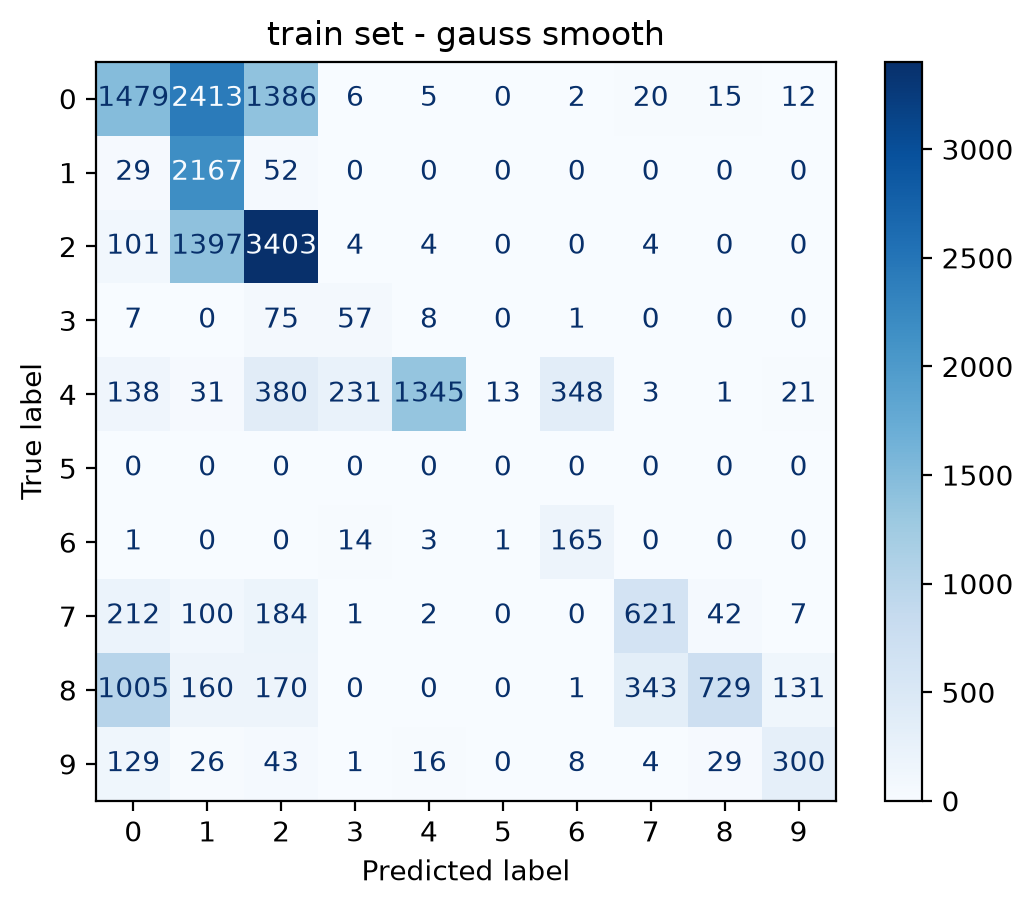

In [37]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("train set - gauss smooth")
# plt.savefig("plots/train_gauss_smooth.pdf")
plt.show()

### Testing

#### without filter

In [38]:
X_test_gray.shape

(2179, 69, 69)

In [39]:
# Min-max normalization (per-image)

X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

In [40]:
X_flat = X_norm[..., np.newaxis]
y_labels = np.argmax(y_test, axis=1)

In [41]:
y_pred = model.predict(X_flat)
y_pred = np.argmax(y_pred, axis=1)

69/69 [==============================] - 0s 5ms/step


In [42]:
y_true = np.argmax(y_test, axis=1)

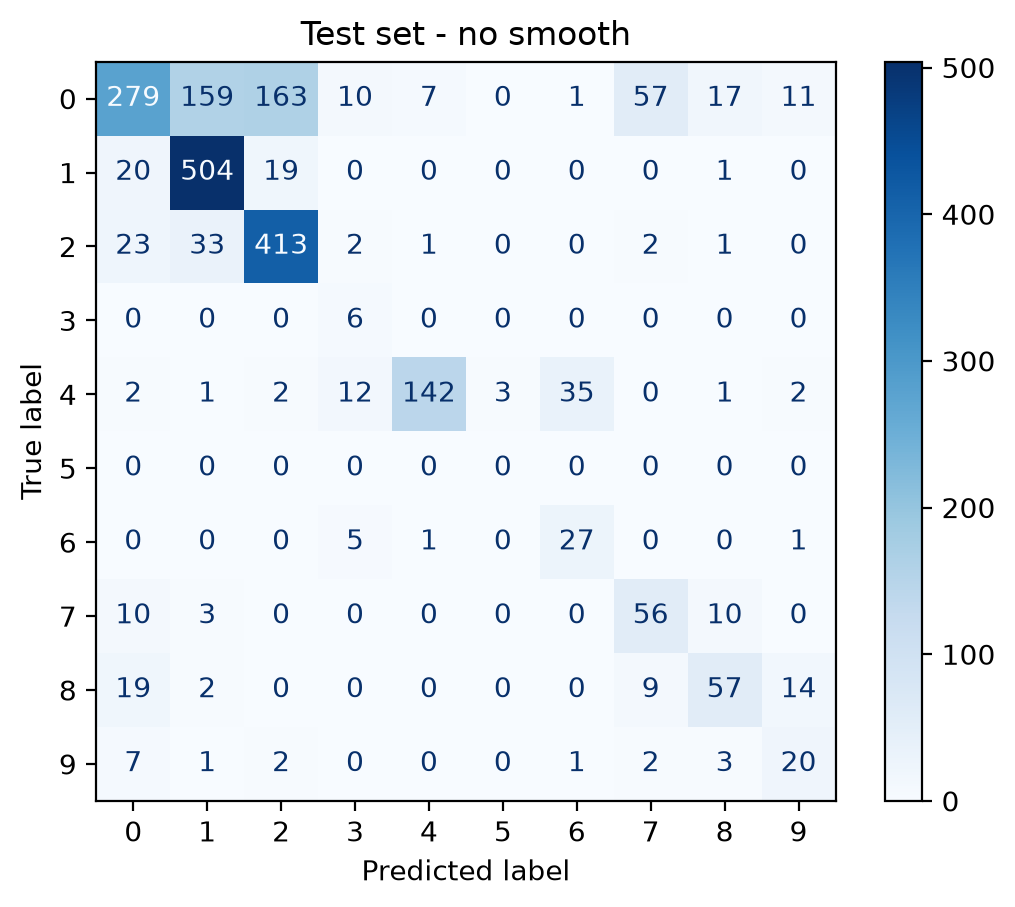

In [43]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set - no smooth")
# plt.savefig("plots/test_no_smooth.pdf")
plt.show()

In [44]:
# accuracy

acc = np.mean(y_true == y_pred)
print(f"Test set accuracy (without smooth) : {acc:.4f}")

Test set accuracy (without smooth) : 0.6902


In [45]:
# precision: TP / (TP + FP)
# recall:    TP / (TP + FN)

tps = np.diagonal(cm)
fps_matrix = cm.copy()
np.fill_diagonal(fps_matrix, 0)
fps = np.sum(fps_matrix, axis=0)
fns = np.sum(fps_matrix, axis=1)

In [46]:
import numpy as np

precisions = np.divide(tps, tps + fps, out=np.zeros_like(tps, dtype=float), where=(tps + fps) != 0)
recalls = np.divide(tps, tps + fns, out=np.zeros_like(tps, dtype=float), where=(tps + fns) != 0)
# f1s = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

In [47]:
print("Test set performance (no smooth)")
print(f"precision: {np.mean(precisions)}")
print(f"recall: {np.mean(recalls)}")

Test set performance (no smooth)
precision: 0.5209555291420593
recall: 0.6525141488379252


In [48]:
X_min = X_test_gray.min(axis=(1,2), keepdims=True)  
X_max = X_test_gray.max(axis=(1,2), keepdims=True)
X_norm = (X_test_gray - X_min) / (X_max - X_min + 1e-8)  

X_gauss = gaussian_filter(X_norm, sigma=1, axes=[1,2])
X_flat = X_gauss[..., np.newaxis]

In [49]:
y_pred = gauss_model.predict(X_flat)
y_pred = np.argmax(y_pred, axis=1)

69/69 [==============================] - 0s 3ms/step


#### with filter

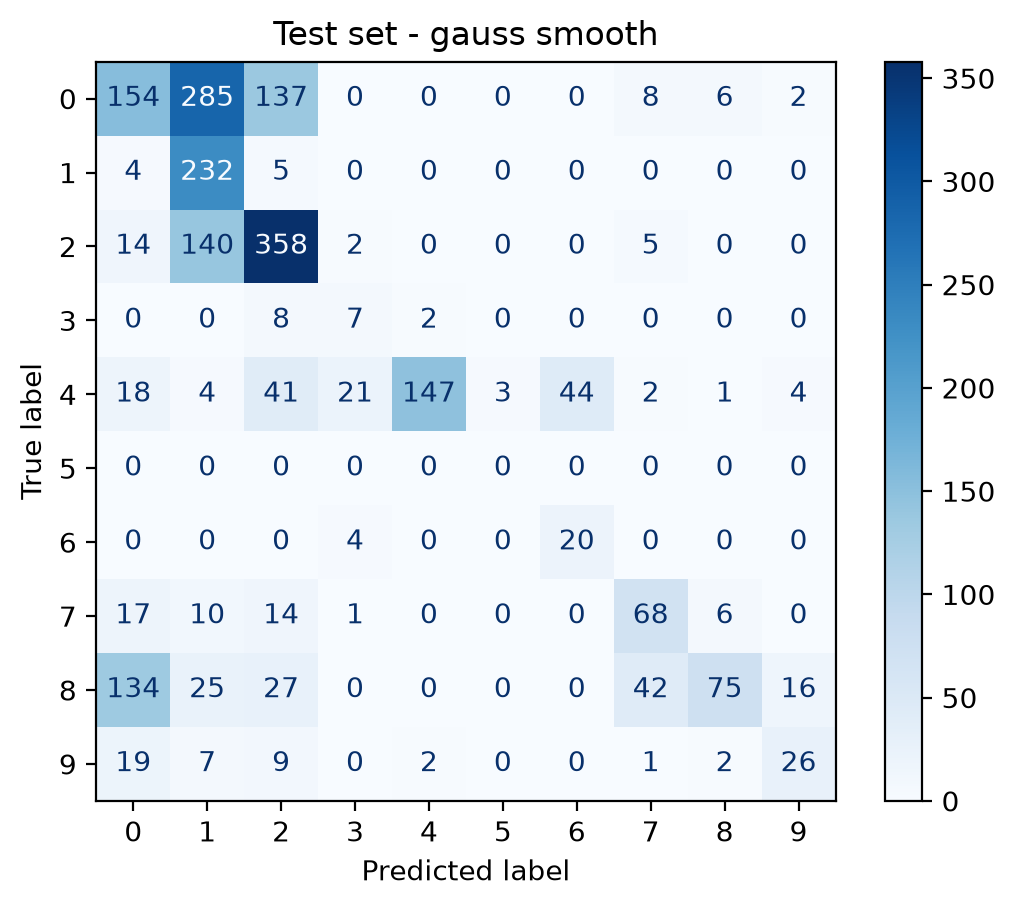

In [50]:
cm = confusion_matrix(y_pred, y_true)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Test set - gauss smooth")
# plt.savefig("plots/test_gauss_smooth.pdf")
plt.show()

In [59]:
# accuracy

acc = np.mean(y_true == y_pred)
print(f"Test set accuracy (smooth) : {acc:.4f}")

Test set accuracy (smooth) : 0.4989


In [52]:
# precision: TP / (TP + FP)
# recall:    TP / (TP + FN)

tps = np.diagonal(cm)
fps_matrix = cm.copy()
np.fill_diagonal(fps_matrix, 0)
fps = np.sum(fps_matrix, axis=0)
fns = np.sum(fps_matrix, axis=1)

In [53]:
import numpy as np

precisions = np.divide(tps, tps + fps, out=np.zeros_like(tps, dtype=float), where=(tps + fps) != 0)
recalls = np.divide(tps, tps + fns, out=np.zeros_like(tps, dtype=float), where=(tps + fns) != 0)
# f1s = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

In [60]:
print("Test set performance (smooth)")
print(f"precision: {np.mean(precisions)}")
print(f"recall: {np.mean(recalls)}")

Test set performance (smooth)
precision: 0.4756147247271694
recall: 0.4888722312004143


### Network inspect

1/1 [==============================] - 0s 241ms/step


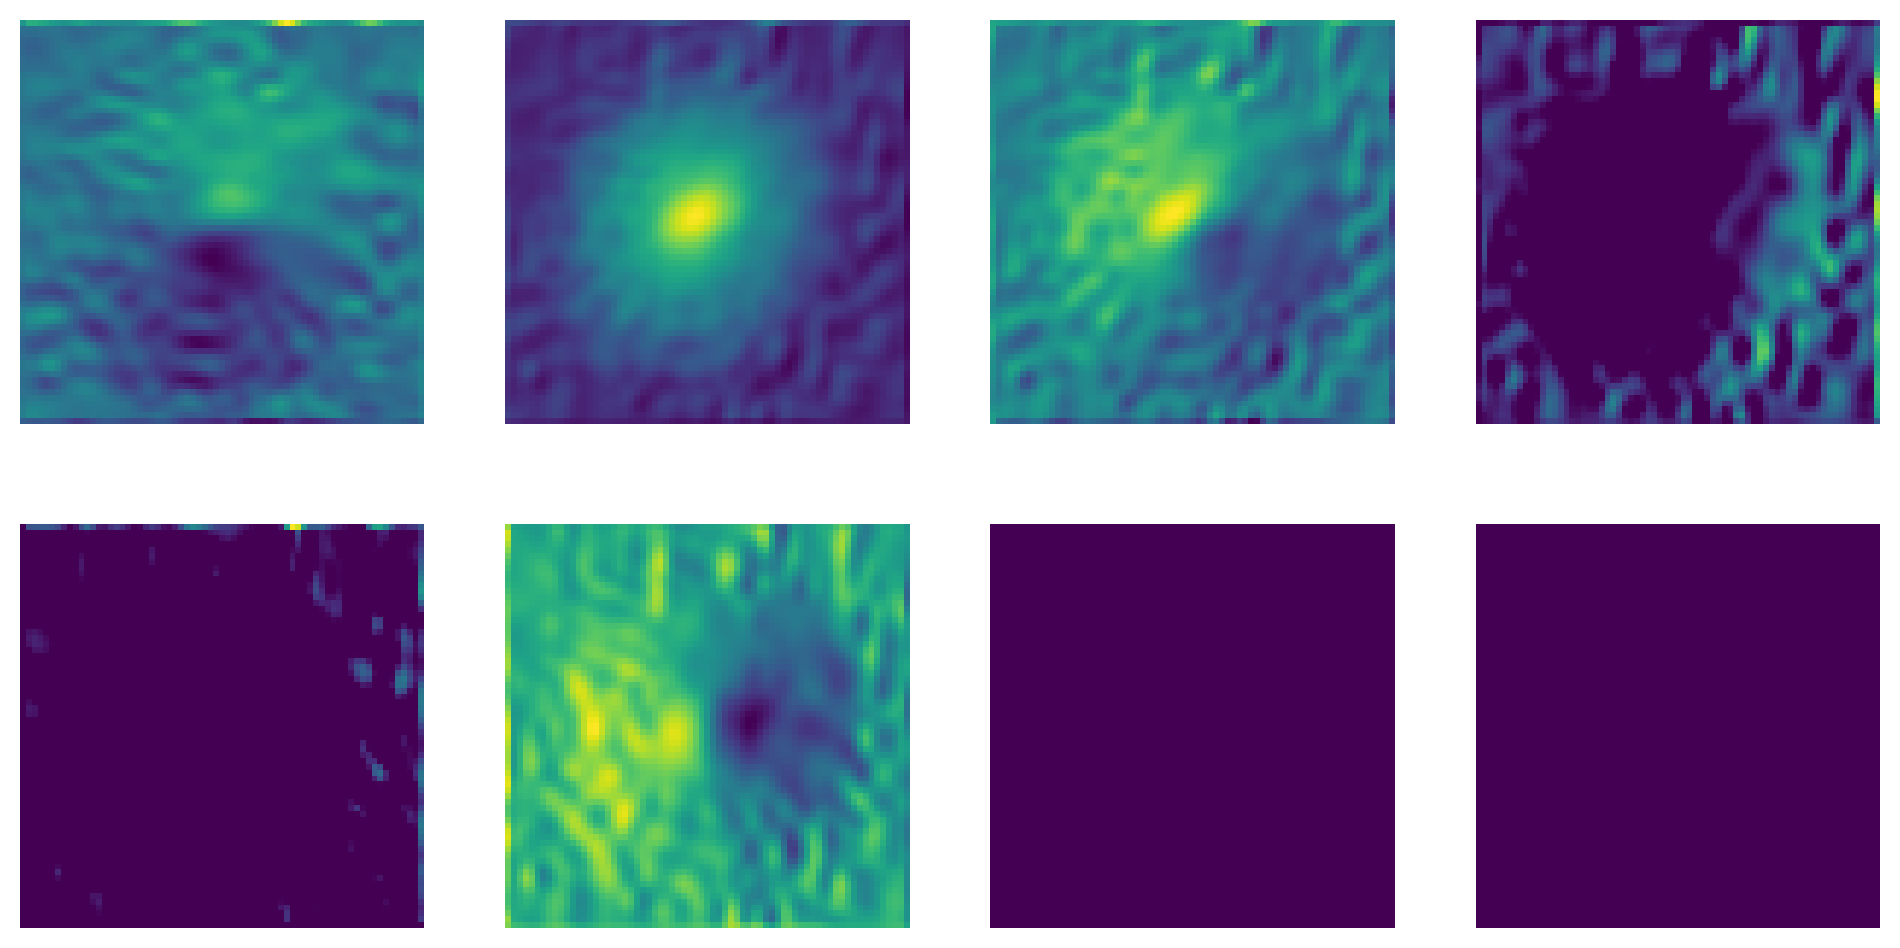

In [55]:
from tensorflow.keras.models import Model

layer_outputs = [layer.output for layer in model.layers if 'conv' in layer.name]
activation_model = Model(inputs=model.input, outputs=layer_outputs)

img = X_flat_gauss[0:1]  # one sample, shape (1, 69, 69, 1)
activations = activation_model.predict(img)

first_layer_activation = activations[0]  # (1, 69, 69, 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
# plt.title("1st layer feature map - no smooth")
# plt.savefig("plots/1LayerFM_no_smooth.png")
plt.show()

1/1 [==============================] - 0s 59ms/step


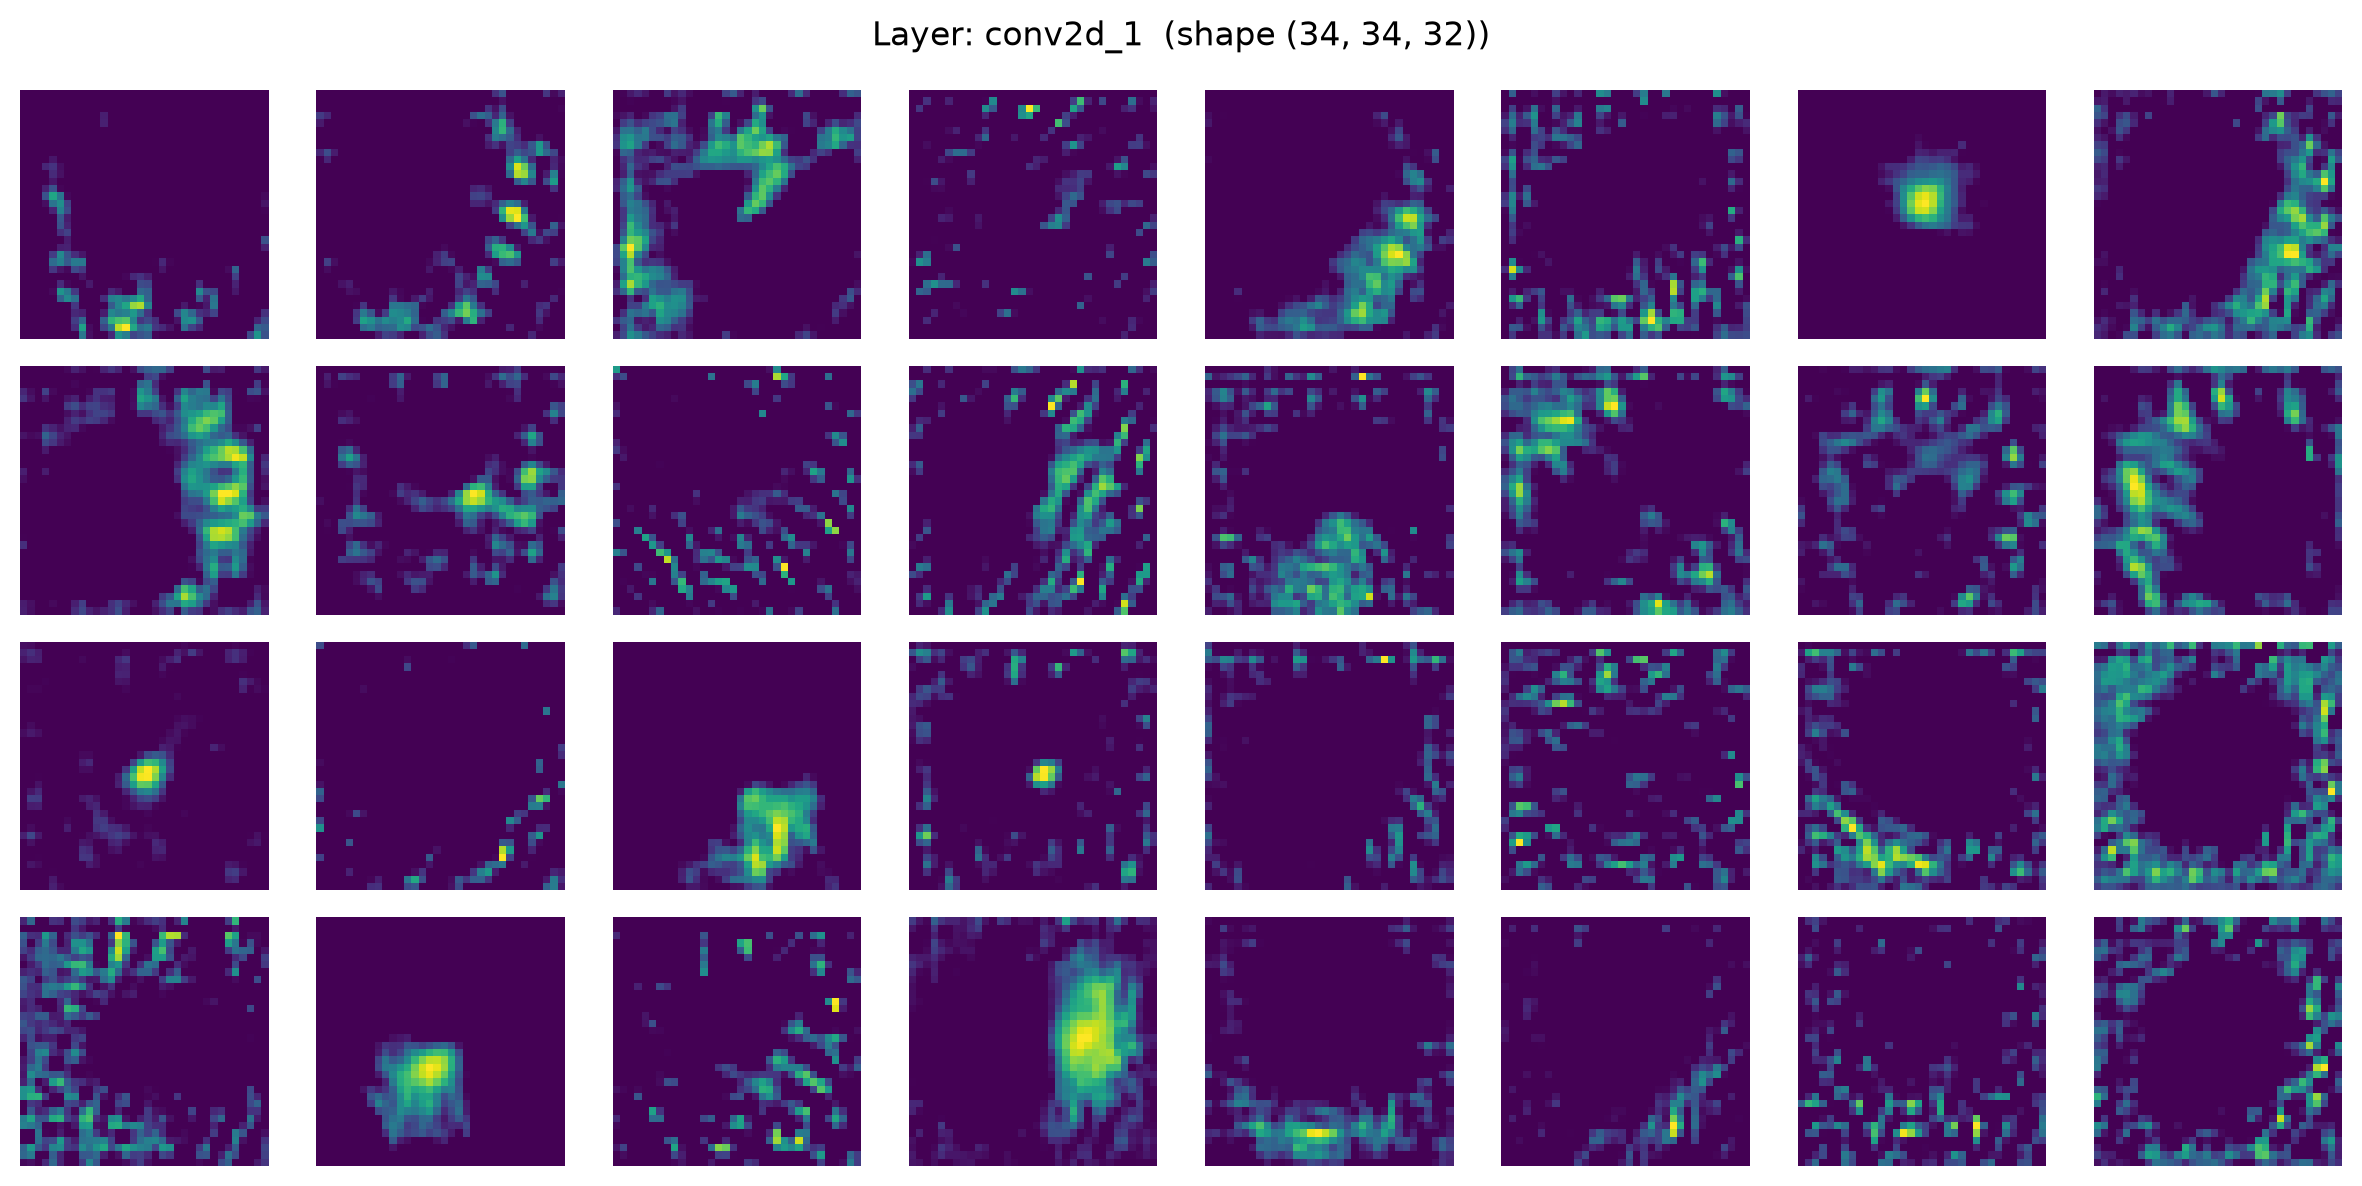

In [56]:
# 2. Grab every conv layer's output
conv_layers = [layer for layer in model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]
layer_names = [layer.name for layer in conv_layers]

activation_model = Model(inputs=model.input, outputs=layer_outputs)
activations = activation_model.predict(img)

# 3. Plot ONLY the second conv layer (index 1)
layer_name = layer_names[1]
activation = activations[1]

n_channels = activation.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
fig.suptitle(f"Layer: {layer_name}  (shape {activation.shape[1:]})", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
# plt.title("2nd layer feature map - no smooth")
# plt.savefig("plots/2LayerFM_no_smooth.pdf")
plt.show()

1/1 [==============================] - 0s 57ms/step


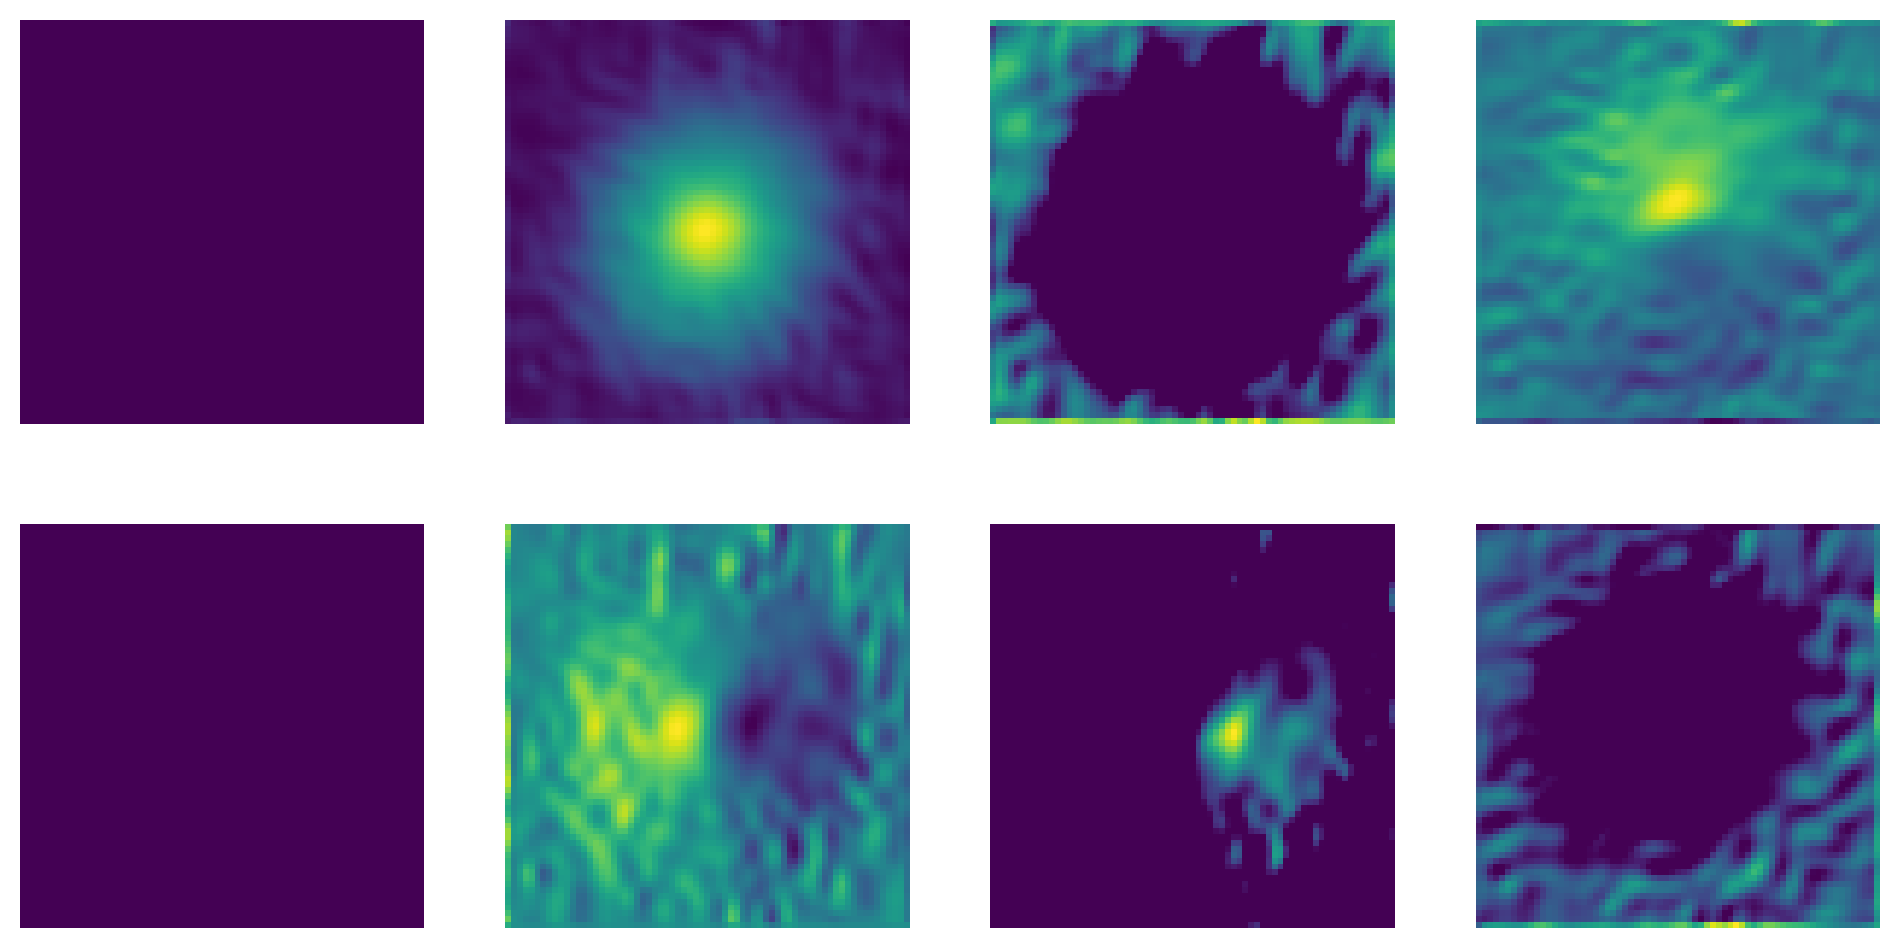

In [57]:
layer_outputs = [layer.output for layer in gauss_model.layers if 'conv' in layer.name]
activation_model = Model(inputs=gauss_model.input, outputs=layer_outputs)

img = X_flat_gauss[0:1]  # one sample, shape (1, 69, 69, 1)
activations = activation_model.predict(img)

first_layer_activation = activations[0]  # (1, 69, 69, 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')
# plt.title("1st layer feature map - gauss smooth")
# plt.savefig("plots/1LayerFM_gauss_smooth.png")
plt.show()

1/1 [==============================] - 0s 65ms/step


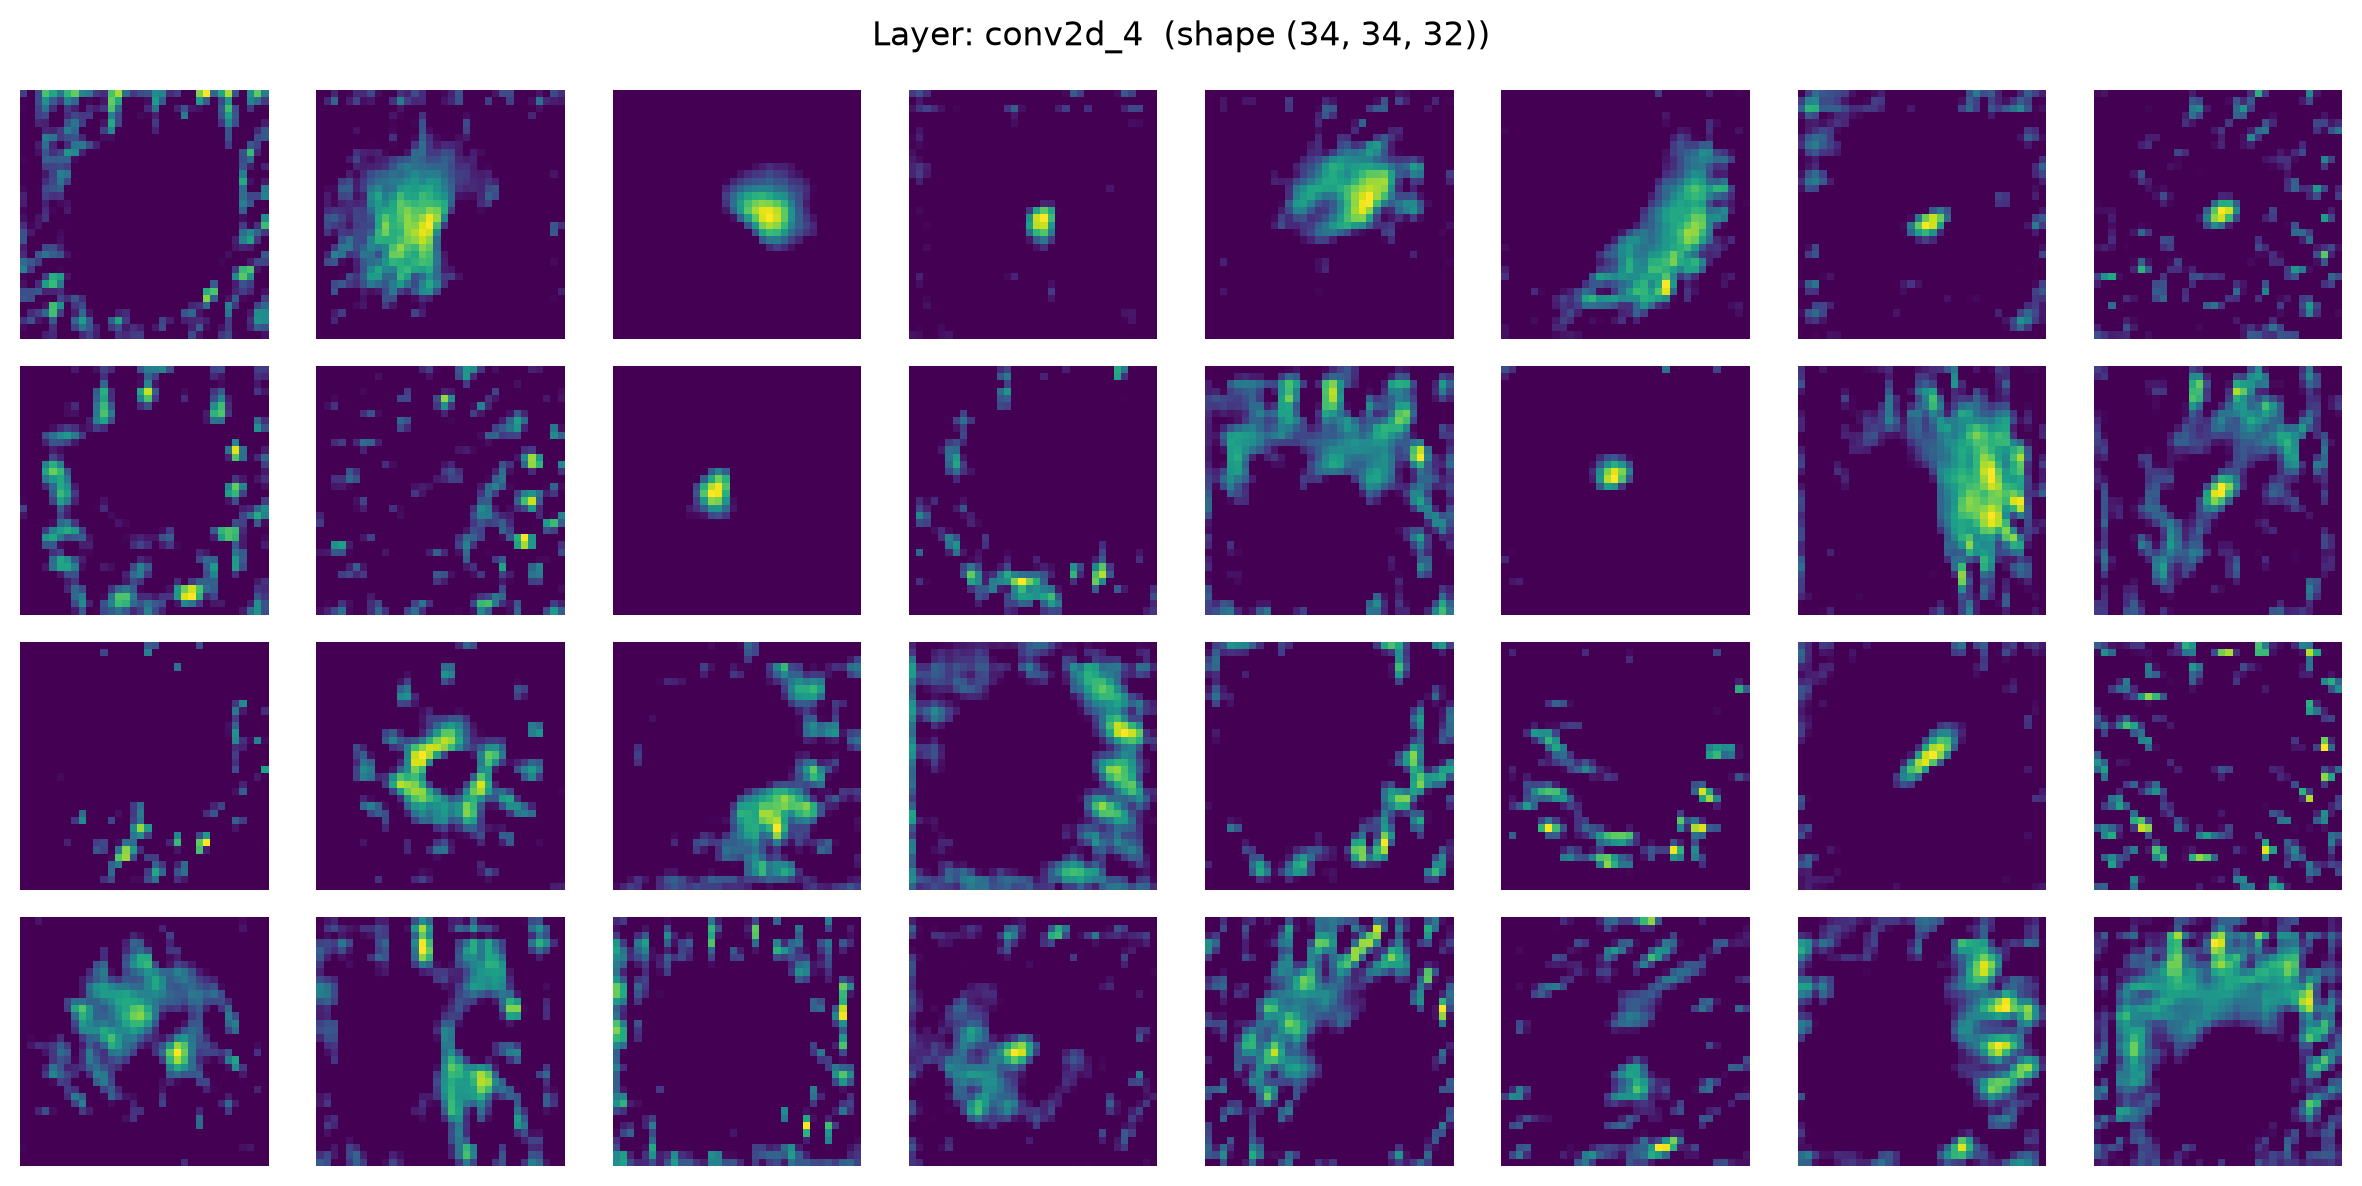

In [58]:
# 2. Grab every conv layer's output
conv_layers = [layer for layer in gauss_model.layers if 'conv' in layer.name]
layer_outputs = [layer.output for layer in conv_layers]
layer_names = [layer.name for layer in conv_layers]

activation_model = Model(inputs=gauss_model.input, outputs=layer_outputs)
activations = activation_model.predict(img)

# 3. Plot ONLY the second conv layer (index 1)
layer_name = layer_names[1]
activation = activations[1]

n_channels = activation.shape[-1]
n_cols = 8
n_rows = int(np.ceil(n_channels / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
fig.suptitle(f"Layer: {layer_name}  (shape {activation.shape[1:]})", fontsize=12)

for i, ax in enumerate(axes.flat):
    if i < n_channels:
        ax.imshow(activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.tight_layout()
# plt.title("2nd layer feature map - gauss smooth")
# plt.savefig("plots/2LayerFM_gauss_smooth.pdf")
plt.show()